# DESI DR1 ELG 2PCF vs GALFORM L800/lc16

Compares DESI DR1 monopole xi(r) to GALFORM real-space xi(r) at matched redshifts.

**Bins:** z=[0.8,1.1) -> iz=176; z=[1.1,1.6) -> iz=155.

> DESI is measured in redshift space; GALFORM xi(r) is real space.

## 0  Submit compute jobs (run once)

```bash
bash scripts/submit_desi_dr1_campaign.sh
```
Outputs: `data/desi/csvs/desi_elg_dr1_xi_z*_nran*.csv`

In [1]:
import sys
from pathlib import Path

def find_repo_root(start=None):
    if start is None: start = Path.cwd()
    for c in [start, *start.parents]:
        if (c / 'pyproject.toml').exists() and (c / 'src').exists():
            return c
    raise FileNotFoundError('repo root not found')

repo = find_repo_root()
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from galform_analysis.utils.matplotlib_config import setconfig

plt.close('all')
mpl.rcdefaults()
setconfig()
mpl.rcParams['lines.marker'] = 'None'
print('Repo root:', repo)


Repo root: /cosma/apps/durham/dc-hick2/galform_analysis


## 1  Load DESI DR1 xi(r)

In [2]:
N_RAN = 4   # match n-ran used in compute job

desi_dir = repo / 'data' / 'desi' / 'csvs'
desi_bins = {'0.8-1.1': (0.8, 1.1), '1.1-1.6': (1.1, 1.6)}

desi_xi = {}
for label, (z_min, z_max) in desi_bins.items():
    fn = desi_dir / f'desi_elg_dr1_xi_z{z_min:.1f}_{z_max:.1f}_nran{N_RAN}.csv'
    if fn.exists():
        desi_xi[label] = pd.read_csv(fn)
        print(f'Loaded DR1 {label}: {fn.name}')
    else:
        print(f'NOT FOUND — submit compute job first: {fn}')

# 1% survey pycorr pair-count files (reference)
old_path = repo / 'data' / 'desi'
catalog  = 'ELG_NScomb'
wt_str   = 'default_bitwise_angular_FKP'

def load_pycorr_xi(zlim_str):
    fn = old_path / f'allcounts_{catalog}_{zlim_str}_{wt_str}_log_njack128_nran18_split20.npy'
    if not fn.exists():
        return None
    d = np.load(fn, allow_pickle=True).item()
    def nw(c): return c['wcounts'] / c['wnorm']
    dd, dr, rd, rr = nw(d['D1D2']), nw(d['D1R2']), nw(d['R1D2']), nw(d['R1R2'])
    xi_smu = np.where(rr > 0, (dd - dr - rd + rr) / rr, np.nan)
    s_e = d['D1D2']['edges'][0]
    s_c = 0.5 * (s_e[:-1] + s_e[1:])
    xi_r = np.nanmean(xi_smu, axis=1)
    return pd.DataFrame({'s': s_c, 'xi0': xi_r})

desi_1pct = {}
for zlim_str, label in [('0.8_1.1', '0.8-1.1'), ('1.1_1.6', '1.1-1.6')]:
    df = load_pycorr_xi(zlim_str)
    if df is not None:
        desi_1pct[label] = df
        print(f'Loaded 1% survey {label}')
    else:
        print(f'1% survey {label}: not found')


Loaded DR1 0.8-1.1: desi_elg_dr1_xi_z0.8_1.1_nran4.csv
Loaded DR1 1.1-1.6: desi_elg_dr1_xi_z1.1_1.6_nran4.csv


/tmp/ipykernel_3530037/251679729.py:30: RuntimeWarning: Mean of empty slice
  xi_r = np.nanmean(xi_smu, axis=1)


Loaded 1% survey 0.8-1.1
Loaded 1% survey 1.1-1.6


## 2  Load GALFORM simulation xi(r)

In [3]:
# iz155 z~1.496 -> DESI 1.1-1.6
# iz176 z~1.007 -> DESI 0.8-1.1  (run submit_desi_fullbox_nomasscut.sh if missing)
sim_base = repo / 'data' / 'halo_sampling_5_corrfunc_fullbox_1024' / 'lc16'

sim_xi = {}
for label, iz, mhalo in [('0.8-1.1', 176, 'mhalo_1e11'), ('1.1-1.6', 155, 'mhalo_1e11')]:
    fn = (sim_base / f'iz{iz}' / 'ntotal_1024' / 'custom' /
          mhalo / 'centrals_0' / 'nsubvol_1024' /
          f'halo_sampling_convergence_corrfunc_L800_iz{iz}.csv')
    if fn.exists():
        sim_xi[label] = pd.read_csv(fn)
        print(f'Loaded sim {label} (iz={iz})')
    else:
        print(f'Sim {label} (iz={iz}): NOT FOUND — run submit_desi_fullbox_nomasscut.sh')

# Subvol-weighted fallback for iz155
sim_w_base = repo / 'data' / '2pcf' / 'ls_wp' / 'lc16'
sim_w_xi = {}
for label, iz, mhalo in [('1.1-1.6', 155, 'mhalo_1e11')]:
    fn = (sim_w_base / f'iz{iz}' / 'ntotal_1024' /
          'random_highN_single_seed731000' / mhalo / 'centrals_0' / 'nsubvol_1024' /
          f'halo_sampling_convergence_weighted_L800_iz{iz}.csv')
    if fn.exists():
        sim_w_xi[label] = pd.read_csv(fn)
        print(f'Loaded weighted sim {label}')


Sim 0.8-1.1 (iz=176): NOT FOUND — run submit_desi_fullbox_nomasscut.sh
Loaded sim 1.1-1.6 (iz=155)
Loaded weighted sim 1.1-1.6


## 3  Plot: DR1 vs GALFORM

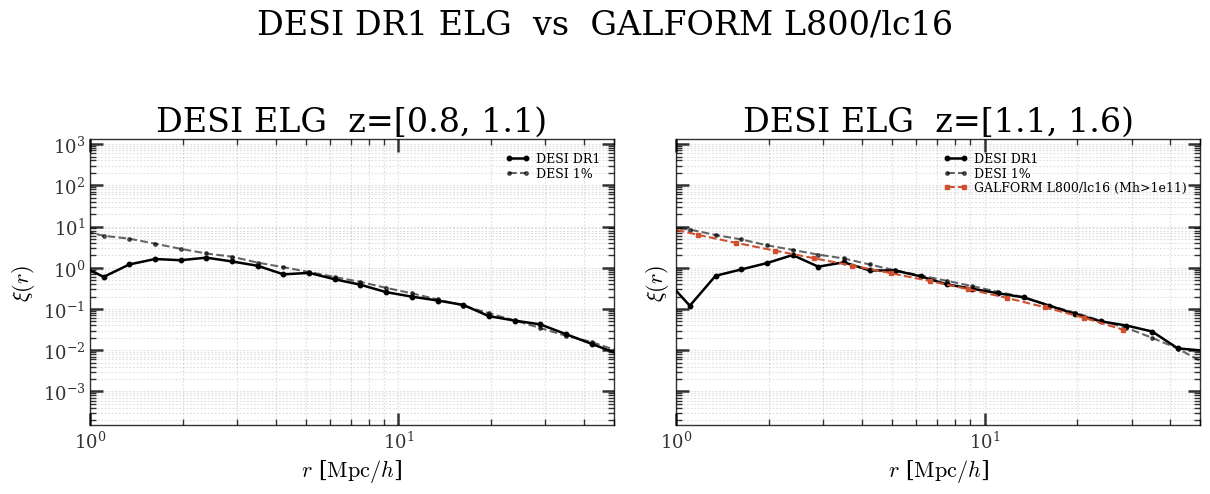

Saved to _plots/


In [4]:
colors  = {'0.8-1.1': 'black',   '1.1-1.6': '#d04f2f'}
sim_col = {'0.8-1.1': '#1f77b4', '1.1-1.6': '#1f77b4'}
zlabels = {'0.8-1.1': 'z=[0.8, 1.1)', '1.1-1.6': 'z=[1.1, 1.6)'}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharey=True)

for ax, label in zip(axes, ['0.8-1.1', '1.1-1.6']):

    # DESI DR1
    if label in desi_xi:
        df = desi_xi[label]
        m  = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
        ax.loglog(df['s'][m], df['xi0'][m],
                  lw=1.8, marker='o', markersize=3.2,
                  color='black', label='DESI DR1')

    # 1% survey
    if label in desi_1pct:
        df = desi_1pct[label]
        m  = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
        ax.loglog(df['s'][m], df['xi0'][m],
                  lw=1.5, ls='--', marker='o', markersize=2.5, alpha=0.6,
                  color='black', label='DESI 1%')

    # GALFORM fullbox
    if label in sim_xi:
        df = sim_xi[label]
        m  = np.isfinite(df['xi']) & (df['xi'] > 0) & (df['r'] > 0)
        ax.loglog(df['r'][m], df['xi'][m],
                  lw=1.5, ls='--', marker='s', markersize=3.0,
                  color='#d04f2f', label='GALFORM L800/lc16 (Mh>1e11)')
    elif label in sim_w_xi:
        df = sim_w_xi[label]
        m  = np.isfinite(df['xi_corrected']) & (df['xi_corrected'] > 0) & (df['r'] > 0)
        ax.loglog(df['r'][m], df['xi_corrected'][m],
                  lw=1.5, ls='--', marker='s', markersize=3.0,
                  color='#d04f2f', label='GALFORM L800/lc16 weighted')

    ax.set_xlim(1, 50)
    ax.set_xlabel(r'$r$ [$\mathrm{Mpc}/h$]')
    ax.set_ylabel(r'$\xi(r)$')
    ax.set_title(f'DESI ELG  {zlabels[label]}')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=9)

fig.suptitle('DESI DR1 ELG  vs  GALFORM L800/lc16', y=1.01)
fig.tight_layout()
plot_dir = repo / '_plots'
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / 'desi_dr1_vs_galform_xi.pdf', bbox_inches='tight')
fig.savefig(plot_dir / 'desi_dr1_vs_galform_xi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to _plots/')


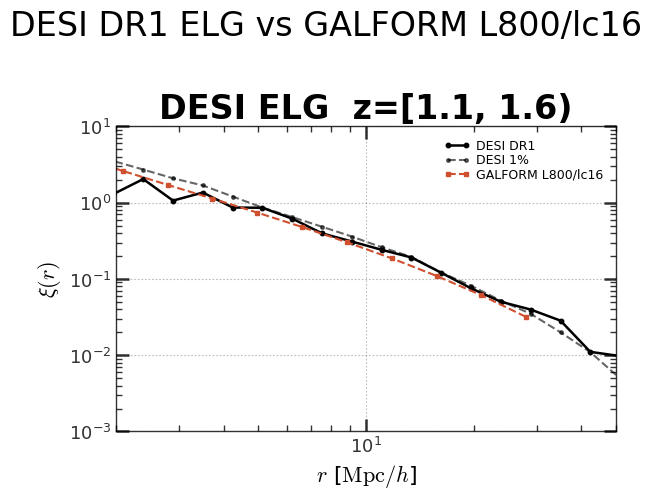

Saved to _plots/


In [5]:
colors  = {'0.8-1.1': 'black',   '1.1-1.6': '#d04f2f'}
sim_col = {'0.8-1.1': '#1f77b4', '1.1-1.6': '#1f77b4'}
zlabels = {'0.8-1.1': 'z=[0.8, 1.1)', '1.1-1.6': 'z=[1.1, 1.6)'}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['axes.labelweight'] = 'medium'

label = '1.1-1.6'
fig, ax = plt.subplots(1, 1, figsize=(6.4, 5.2))

# DESI DR1
if label in desi_xi:
    df = desi_xi[label]
    m = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
    ax.loglog(df['s'][m], df['xi0'][m],
              lw=1.8, marker='o', markersize=3.2,
              color='black', label='DESI DR1')

# 1% survey
if label in desi_1pct:
    df = desi_1pct[label]
    m = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
    ax.loglog(df['s'][m], df['xi0'][m],
              lw=1.5, ls='--', marker='o', markersize=2.5, alpha=0.6,
              color='black', label='DESI 1%')

# GALFORM fullbox
if label in sim_xi:
    df = sim_xi[label]
    m = np.isfinite(df['xi']) & (df['xi'] > 0) & (df['r'] > 0)
    ax.loglog(df['r'][m], df['xi'][m],
              lw=1.5, ls='--', marker='s', markersize=3.0,
              color='#d04f2f', label='GALFORM L800/lc16')
elif label in sim_w_xi:
    df = sim_w_xi[label]
    m = np.isfinite(df['xi_corrected']) & (df['xi_corrected'] > 0) & (df['r'] > 0)
    ax.loglog(df['r'][m], df['xi_corrected'][m],
              lw=1.5, ls='--', marker='s', markersize=3.0,
              color='#d04f2f', label='GALFORM L800/lc16 weighted')

ax.set_xlim(2, 50)
ax.set_ylim(1e-3, 1e1)
ax.set_xlabel(r'$r$ [$\mathrm{Mpc}/h$]')
ax.set_ylabel(r'$\xi(r)$')
ax.set_title(f'DESI ELG  {zlabels[label]}')
ax.legend(fontsize=9, frameon=False)

fig.suptitle('DESI DR1 ELG vs GALFORM L800/lc16', y=0.98)
fig.tight_layout()
plot_dir = repo / '_plots'
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / 'desi_dr1_vs_galform_xi_right_panel.pdf', bbox_inches='tight')
fig.savefig(plot_dir / 'desi_dr1_vs_galform_xi_right_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to _plots/')

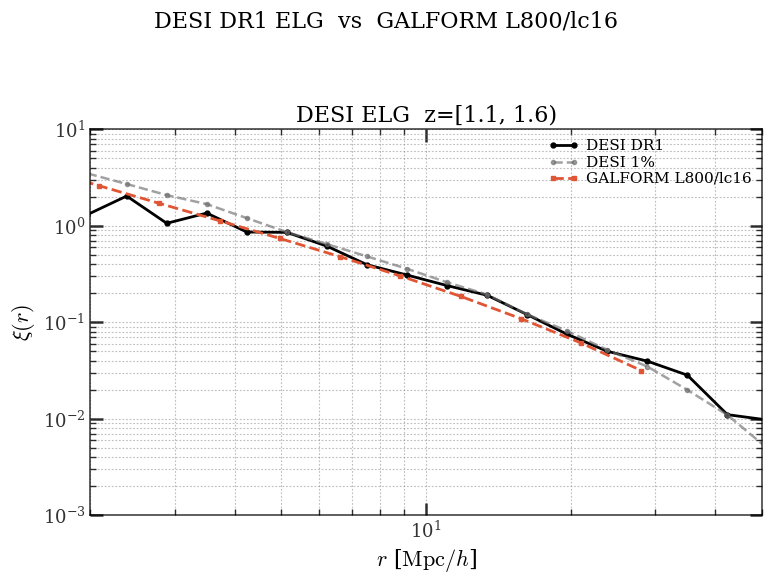

Saved to _plots/


In [6]:
colors  = {'0.8-1.1': 'black',   '1.1-1.6': '#d04f2f'}
sim_col = {'0.8-1.1': '#1f77b4', '1.1-1.6': '#1f77b4'}
zlabels = {'0.8-1.1': 'z=[0.8, 1.1)', '1.1-1.6': 'z=[1.1, 1.6)'}

import matplotlib as mpl
from galform_analysis.utils.matplotlib_config import setconfig

mpl.rcdefaults()
setconfig({
    'font': {'family': 'serif', 'size': 16},
    'mathtext': {'fontset': 'cm', 'default': 'it'},
    'figure': {'figsize': (8, 6)},
    'axes': {
        'labelsize': 16,
        'labelweight': 'normal',
        'linewidth': 1.1,
        'grid': True,
    },
    'xtick': {'labelsize': 13, 'direction': 'in', 'top': True},
    'ytick': {'labelsize': 13, 'direction': 'in', 'right': True},
    'xtick.major': {'width': 1.8, 'size': 9},
    'xtick.minor': {'width': 1, 'size': 4, 'visible': True},
    'ytick.major': {'width': 1.8, 'size': 9},
    'ytick.minor': {'width': 1, 'size': 4, 'visible': True},
    'grid': {
        'color': 'gray',
        'alpha': 0.5,
        'linestyle': (0, (1.6, 1.6)),
        'linewidth': 0.8,
    },
    'lines': {'linewidth': 2.5},
    'legend': {
        'fontsize': 12,
        'frameon': False,
        'handlelength': 2.0,
        'handletextpad': 0.5,
        'borderaxespad': 0.8,
    },
})
mpl.rcParams['axes.titleweight'] = 'normal'
mpl.rcParams['axes.labelweight'] = 'normal'

label = '1.1-1.6'
fig, ax = plt.subplots(1, 1)

# DESI DR1
if label in desi_xi:
    df = desi_xi[label]
    m = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
    ax.loglog(df['s'][m], df['xi0'][m],
              lw=2.0, marker='o', markersize=3.5,
              color='black', markerfacecolor='black', markeredgecolor='black',
              label='DESI DR1')

# 1% survey
if label in desi_1pct:
    df = desi_1pct[label]
    m = np.isfinite(df['xi0']) & (df['xi0'] > 0) & (df['s'] > 0)
    ax.loglog(df['s'][m], df['xi0'][m],
              lw=1.8, ls='--', marker='o', markersize=3.0, alpha=0.65,
              color='#6f6f6f', markerfacecolor='#6f6f6f', markeredgecolor='#6f6f6f',
              label='DESI 1%')

# GALFORM fullbox
if label in sim_xi:
    df = sim_xi[label]
    m = np.isfinite(df['xi']) & (df['xi'] > 0) & (df['r'] > 0)
    ax.loglog(df['r'][m], df['xi'][m],
              lw=2.0, ls='--', marker='s', markersize=3.5,
              color='#e05534', markerfacecolor='#e05534', markeredgecolor='#e05534',
              label='GALFORM L800/lc16')
elif label in sim_w_xi:
    df = sim_w_xi[label]
    m = np.isfinite(df['xi_corrected']) & (df['xi_corrected'] > 0) & (df['r'] > 0)
    ax.loglog(df['r'][m], df['xi_corrected'][m],
              lw=2.0, ls='--', marker='s', markersize=3.5,
              color='#e05534', markerfacecolor='#e05534', markeredgecolor='#e05534',
              label='GALFORM L800/lc16 weighted')

ax.set_xlim(2, 50)
ax.set_ylim(1e-3, 1e1)
ax.set_xlabel(r'$r$ [$\mathrm{Mpc}/h$]')
ax.set_ylabel(r'$\xi(r)$')
ax.set_title(f'DESI ELG  {zlabels[label]}', fontsize=16, pad=6)
ax.grid(True, which='both')
ax.minorticks_on()
ax.legend(loc='upper right', fontsize=11, frameon=False, handlelength=2.0, labelspacing=0.15, borderaxespad=0.4)

fig.suptitle('DESI DR1 ELG  vs  GALFORM L800/lc16', fontsize=16, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plot_dir = repo / '_plots'
plot_dir.mkdir(exist_ok=True)
fig.savefig(plot_dir / 'desi_dr1_vs_galform_xi_right_panel.pdf', bbox_inches='tight')
fig.savefig(plot_dir / 'desi_dr1_vs_galform_xi_right_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to _plots/')

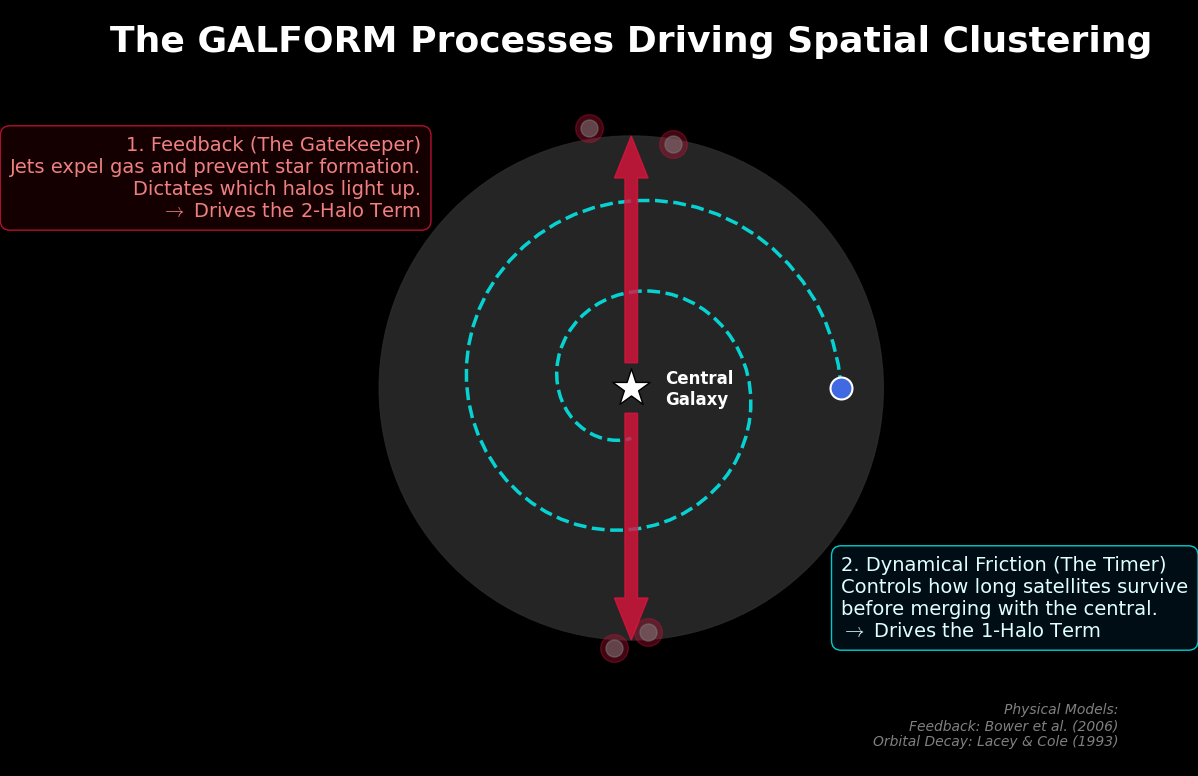

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- SET DARK MODE & FONTS ---
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(12, 8.5), facecolor='black')
ax.set_xlim(0, 12)
ax.set_ylim(0, 9)
ax.set_aspect('equal')
ax.axis('off')

# Main Title
plt.text(6, 8.5, 'The GALFORM Processes Driving Spatial Clustering', 
         fontsize=26, fontweight='bold', ha='center', color='white')

# --- 1. DRAW THE UNIFIED SYSTEM ---
# Main Dark Matter Halo
main_halo = patches.Circle((6, 4.5), 3.0, color='#2a2a2a', alpha=0.9, zorder=1)
ax.add_patch(main_halo)

# Central Galaxy
ax.scatter(6, 4.5, marker='*', color='white', s=800, zorder=4, edgecolors='black')
ax.text(6.4, 4.3, "Central\nGalaxy", color='white', fontsize=12, fontweight='bold')

# --- 2. THE GATEKEEPER (FEEDBACK) ---
# AGN Jets erupting outward
ax.arrow(6, 4.8, 0, 2.2, head_width=0.4, head_length=0.5, fc='crimson', ec='crimson', width=0.15, zorder=3, alpha=0.8)
ax.arrow(6, 4.2, 0, -2.2, head_width=0.4, head_length=0.5, fc='crimson', ec='crimson', width=0.15, zorder=3, alpha=0.8)

# Gas being blown away at the edges
ax.scatter([5.5, 6.5, 5.8, 6.2], [7.6, 7.4, 1.4, 1.6], s=400, color='crimson', alpha=0.3, zorder=2)
ax.scatter([5.5, 6.5, 5.8, 6.2], [7.6, 7.4, 1.4, 1.6], s=150, color='gray', alpha=0.5, zorder=2)

# Feedback Annotation
ax.text(3.5, 7.0, "1. Feedback (The Gatekeeper)\nJets expel gas and prevent star formation.\nDictates which halos light up.\n$\\rightarrow$ Drives the 2-Halo Term", 
        color='lightcoral', fontsize=14, ha='right', va='center',
        bbox=dict(facecolor='#1a0000', edgecolor='crimson', pad=10, boxstyle='round,pad=0.5', alpha=0.8))

# --- 3. THE SURVIVAL TIMER (DYNAMICAL FRICTION) ---
# Satellite spiraling in
theta = np.linspace(0, 3.5*np.pi, 100)
r = np.linspace(2.5, 0.6, 100)
x_spiral = 6 + r * np.cos(theta)
y_spiral = 4.5 + r * np.sin(theta)

ax.plot(x_spiral, y_spiral, color='cyan', linestyle='--', linewidth=2.5, alpha=0.8, zorder=2)

# Satellite galaxy
ax.scatter(x_spiral[0], y_spiral[0], c='royalblue', s=250, zorder=4, edgecolors='white', linewidth=1.5)

# Friction Annotation
ax.text(8.5, 2.0, "2. Dynamical Friction (The Timer)\nControls how long satellites survive\nbefore merging with the central.\n$\\rightarrow$ Drives the 1-Halo Term", 
        color='lightcyan', fontsize=14, ha='left', va='center',
        bbox=dict(facecolor='#00111a', edgecolor='cyan', pad=10, boxstyle='round,pad=0.5', alpha=0.8))

# --- 4. LITERATURE CITATIONS (THE "PRO-MOVE") ---
citation_text = (
    "Physical Models:\n"
    "Feedback: Bower et al. (2006)\n"
    "Orbital Decay: Lacey & Cole (1993)"
)
ax.text(11.8, 0.2, citation_text, fontsize=10, color='gray', ha='right', va='bottom', style='italic')

plt.tight_layout(pad=0)
plt.savefig('slide_galform_unified_physics.png', dpi=300, bbox_inches='tight')
plt.show()

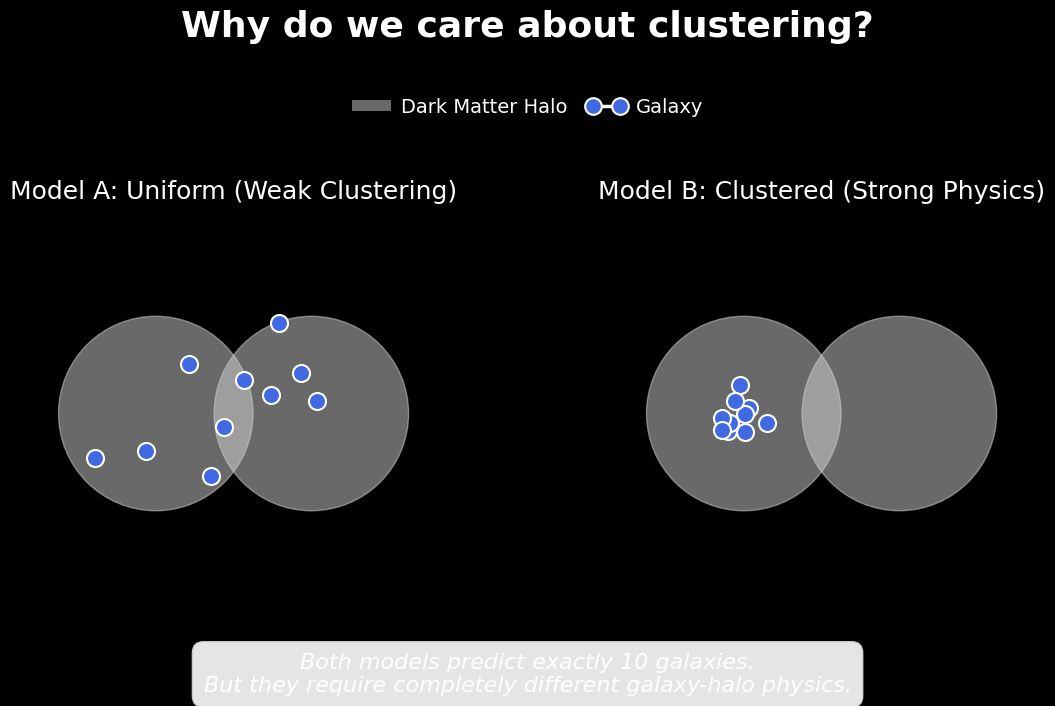

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

# --- 1. SET CLEAN, PROFESSIONAL FONT ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Set up the figure slightly taller to give everything room
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7.5))

# --- 2. TITLES & LEGEND (Spaced Properly) ---
fig.suptitle('Why do we care about clustering?', fontsize=26, fontweight='bold', y=0.95)

legend_elements = [
    mpatches.Patch(facecolor='lightgrey', alpha=0.5, edgecolor='none', label='Dark Matter Halo'),
    Line2D([0], [0], marker='o', color='w', label='Galaxy',
           markerfacecolor='royalblue', markersize=12, markeredgewidth=1.5, markeredgecolor='white')
]

# Place legend cleanly below the main title
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.86),
           ncol=2, fontsize=14, frameon=False)


# --- LEFT PANEL: Uniform Distribution ---
ax1.set_title('Model A: Uniform (Weak Clustering)', fontsize=18, pad=15)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')  # Forces the halos to be perfect circles
ax1.axis('off')

halo1_a = plt.Circle((3, 5), 2.5, color='lightgrey', alpha=0.5, zorder=1)
halo2_a = plt.Circle((7, 5), 2.5, color='lightgrey', alpha=0.5, zorder=1)
ax1.add_patch(halo1_a)
ax1.add_patch(halo2_a)

np.random.seed(42) 
r1, theta1 = np.sqrt(np.random.uniform(0, 2.5**2, 5)), np.random.uniform(0, 2*np.pi, 5)
ax1.scatter(3 + r1*np.cos(theta1), 5 + r1*np.sin(theta1), c='royalblue', s=150, zorder=2, edgecolors='white', linewidth=1.5)

r2, theta2 = np.sqrt(np.random.uniform(0, 2.5**2, 5)), np.random.uniform(0, 2*np.pi, 5)
ax1.scatter(7 + r2*np.cos(theta2), 5 + r2*np.sin(theta2), c='royalblue', s=150, zorder=2, edgecolors='white', linewidth=1.5)


# --- RIGHT PANEL: Clustered Distribution ---
ax2.set_title('Model B: Clustered (Strong Physics)', fontsize=18, pad=15)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')  # Forces the halos to be perfect circles
ax2.axis('off')

halo1_b = plt.Circle((3, 5), 2.5, color='lightgrey', alpha=0.5, zorder=1)
halo2_b = plt.Circle((7, 5), 2.5, color='lightgrey', alpha=0.5, zorder=1)
ax2.add_patch(halo1_b)
ax2.add_patch(halo2_b)

x_clustered = np.random.normal(3, 0.4, 10)
y_clustered = np.random.normal(5, 0.4, 10)
ax2.scatter(x_clustered, y_clustered, c='royalblue', s=150, zorder=2, edgecolors='white', linewidth=1.5)


# --- ANNOTATIONS & LAYOUT ---
fig.text(0.5, 0.04, 'Both models predict exactly 10 galaxies.\nBut they require completely different galaxy-halo physics.', 
         ha='center', fontsize=16, style='italic', 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgrey', pad=8, boxstyle='round,pad=0.5'))

# This is the magic line that prevents text overlap
# It reserves the top 22% of the image for the title/legend, and the bottom 12% for the text box
plt.tight_layout(rect=[0, 0.12, 1, 0.78]) 

plt.savefig('slide_2_clustering_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


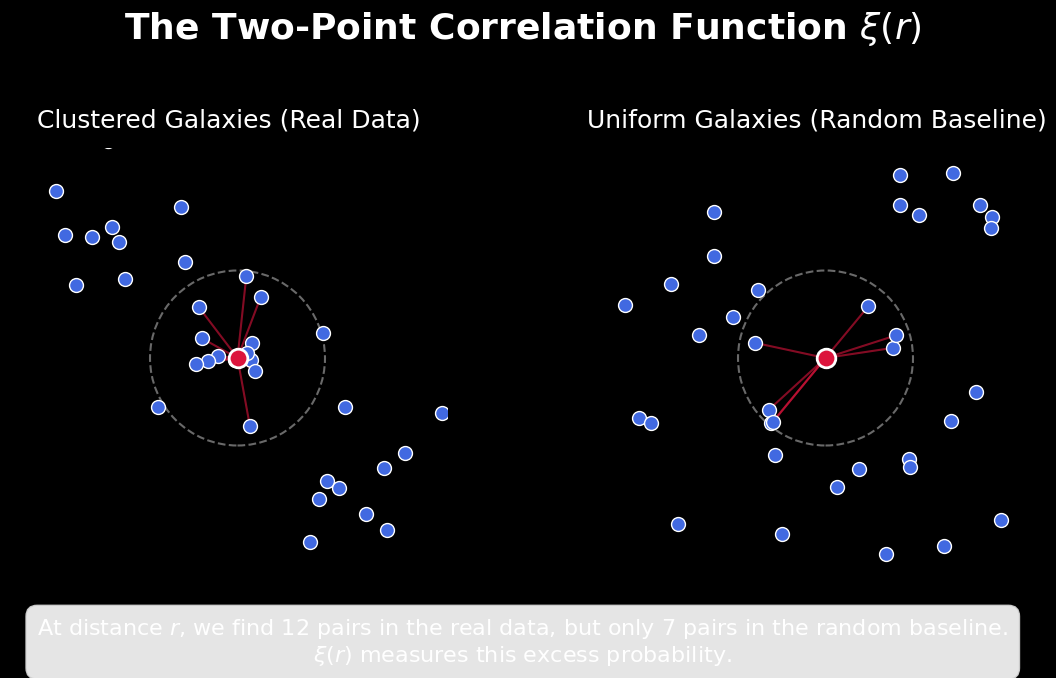

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- 1. SET CLEAN, PROFESSIONAL FONT ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
# Enable LaTeX-style math text for the xi(r) symbol
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'

# Set up the figure 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7.5))

# Main Title
fig.suptitle('The Two-Point Correlation Function $\\xi(r)$', fontsize=26, fontweight='bold', y=0.92)

# Set seed for reproducible random/clustered points
np.random.seed(101)


# --- LEFT PANEL: Clustered Universe (The Data) ---
ax1.set_title('Clustered Galaxies (Real Data)', fontsize=18, pad=15)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')
ax1.axis('off')

# Generate clustered galaxies (3 main clumps)
x_c1, y_c1 = np.random.normal(5, 0.8, 15), np.random.normal(5, 0.8, 15)  # Center clump
x_c2, y_c2 = np.random.normal(2, 1.0, 10), np.random.normal(8, 1.0, 10)  # Top left clump
x_c3, y_c3 = np.random.normal(8, 1.0, 10), np.random.normal(2, 1.0, 10)  # Bottom right clump
x_clustered = np.concatenate([x_c1, x_c2, x_c3])
y_clustered = np.concatenate([y_c1, y_c2, y_c3])

# Plot the background clustered galaxies
ax1.scatter(x_clustered, y_clustered, c='royalblue', s=100, zorder=2, edgecolors='white', linewidth=1)

# Pick a target "Reference" galaxy near the center
target_x, target_y = 5.2, 5.2
search_radius = 2.0

# Highlight the reference galaxy
ax1.scatter(target_x, target_y, c='crimson', s=180, zorder=4, edgecolors='white', linewidth=2, label='Reference Galaxy')

# Draw the search radius circle
circle1 = patches.Circle((target_x, target_y), search_radius, fill=False, color='dimgrey', linestyle='--', linewidth=1.5, zorder=1)
ax1.add_patch(circle1)

# Draw connecting lines to galaxies WITHIN the radius
count_clustered = 0
for x, y in zip(x_clustered, y_clustered):
    dist = np.sqrt((x - target_x)**2 + (y - target_y)**2)
    if dist <= search_radius and dist > 0.1: # avoid drawing line to itself
        ax1.plot([target_x, x], [target_y, y], color='crimson', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
        count_clustered += 1

# Label the radius 'r'
ax1.text(target_x + 0.8, target_y + 1.2, '$r$', color='black', fontsize=16, fontweight='bold', style='italic')


# --- RIGHT PANEL: Random Universe (The Baseline) ---
ax2.set_title('Uniform Galaxies (Random Baseline)', fontsize=18, pad=15)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')

# Generate the exact same number of galaxies, but purely uniform
n_total = len(x_clustered)
x_rand, y_rand = np.random.uniform(0.5, 9.5, n_total), np.random.uniform(0.5, 9.5, n_total)

# Plot the background random galaxies
ax2.scatter(x_rand, y_rand, c='royalblue', s=100, zorder=2, edgecolors='white', linewidth=1)

# Highlight the exact same reference position
ax2.scatter(target_x, target_y, c='crimson', s=180, zorder=4, edgecolors='white', linewidth=2)

# Draw the exact same search radius circle
circle2 = patches.Circle((target_x, target_y), search_radius, fill=False, color='dimgrey', linestyle='--', linewidth=1.5, zorder=1)
ax2.add_patch(circle2)

# Draw connecting lines to galaxies WITHIN the radius
count_random = 0
for x, y in zip(x_rand, y_rand):
    dist = np.sqrt((x - target_x)**2 + (y - target_y)**2)
    if dist <= search_radius and dist > 0.1:
        ax2.plot([target_x, x], [target_y, y], color='crimson', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
        count_random += 1


# --- ANNOTATIONS & LAYOUT ---
# Text box explaining the physics
explanation_text = (
    f"At distance $r$, we find {count_clustered} pairs in the real data, but only {count_random} pairs in the random baseline.\n"
    "$\\xi(r)$ measures this excess probability."
)

fig.text(0.5, 0.05, explanation_text, 
         ha='center', fontsize=16, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgrey', pad=10, boxstyle='round,pad=0.5'))

# Ensure the layout is tight but leaves room for titles and text boxes
plt.tight_layout(rect=[0, 0.12, 1, 0.85]) 

# Save the figure
plt.savefig('slide_3_2pcf.png', dpi=300, bbox_inches='tight')
plt.show()

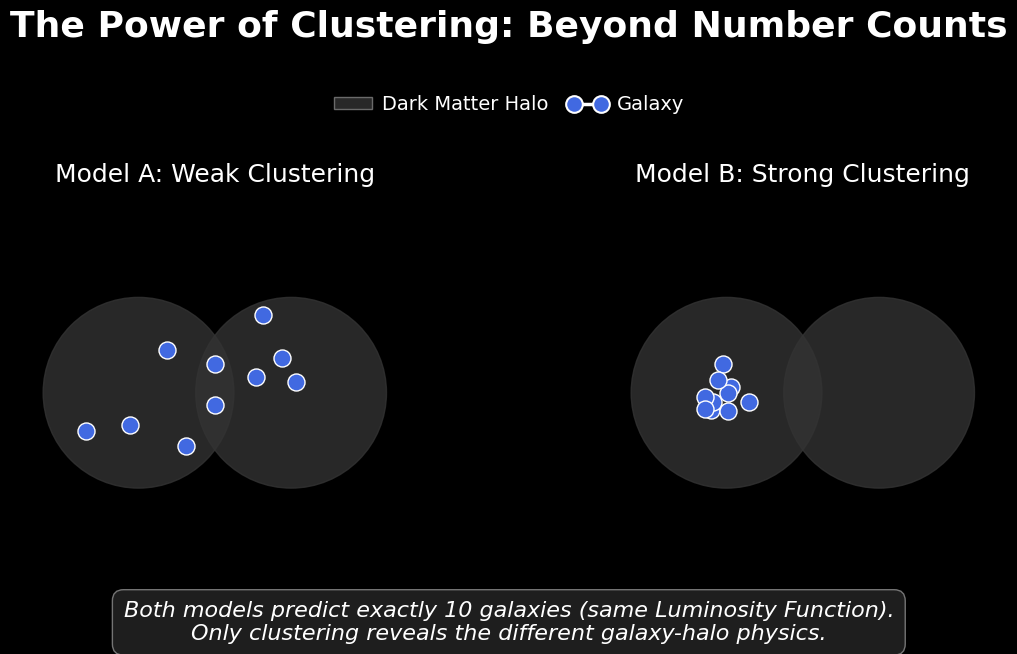

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

# --- 1. SET DARK MODE & FONTS ---
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Set up the figure for a wide presentation slide
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6.5), facecolor='black')

# Main title
fig.suptitle('The Power of Clustering: Beyond Number Counts', 
             fontsize=26, fontweight='bold', y=1.02, color='white')

# --- 2. CREATE A CLEAR LEGEND ---
legend_elements = [
    mpatches.Patch(facecolor='#333333', alpha=0.8, edgecolor='gray', label='Dark Matter Halo'),
    Line2D([0], [0], marker='o', color='w', label='Galaxy',
           markerfacecolor='royalblue', markersize=12, markeredgewidth=1.5, markeredgecolor='white')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.92),
           ncol=2, fontsize=14, frameon=False)

# Shared settings for both panels
def setup_ax(ax, title):
    ax.set_title(title, fontsize=18, pad=15, color='white')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.axis('off')

# --- LEFT PANEL: Model A ---
setup_ax(ax1, 'Model A: Weak Clustering')
# Draw two halos
ax1.add_patch(plt.Circle((3, 5), 2.5, color='#333333', alpha=0.8, zorder=1))
ax1.add_patch(plt.Circle((7, 5), 2.5, color='#333333', alpha=0.8, zorder=1))

# 5 galaxies per halo, scattered (Weak 1-halo term)
np.random.seed(42)
for center in [3, 7]:
    r, theta = np.sqrt(np.random.uniform(0, 2.2**2, 5)), np.random.uniform(0, 2*np.pi, 5)
    ax1.scatter(center + r*np.cos(theta), 5 + r*np.sin(theta), 
                c='royalblue', s=150, zorder=2, edgecolors='white', linewidth=1)

# --- RIGHT PANEL: Model B ---
setup_ax(ax2, 'Model B: Strong Clustering')
# Draw same two halos
ax2.add_patch(plt.Circle((3, 5), 2.5, color='#333333', alpha=0.8, zorder=1))
ax2.add_patch(plt.Circle((7, 5), 2.5, color='#333333', alpha=0.8, zorder=1))

# All 10 galaxies clumped in one halo (Strong 1-halo term)
x_clustered = np.random.normal(3, 0.4, 10)
y_clustered = np.random.normal(5, 0.4, 10)
ax2.scatter(x_clustered, y_clustered, c='royalblue', s=150, zorder=2, edgecolors='white', linewidth=1)

# --- 3. THE "TAKEAWAY" ANNOTATION ---
explanation = (
    "Both models predict exactly 10 galaxies (same Luminosity Function).\n"
    "Only clustering reveals the different galaxy-halo physics."
)
fig.text(0.5, 0.05, explanation, ha='center', fontsize=16, style='italic', color='white',
         bbox=dict(facecolor='#222222', alpha=0.9, edgecolor='gray', pad=10, boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.1, 1, 0.85])
plt.savefig('slide_2_clustering_v2.png', dpi=300, bbox_inches='tight')
plt.show()

Generating GIF... This will take a few seconds.
Saved as slide_3_animation.gif!


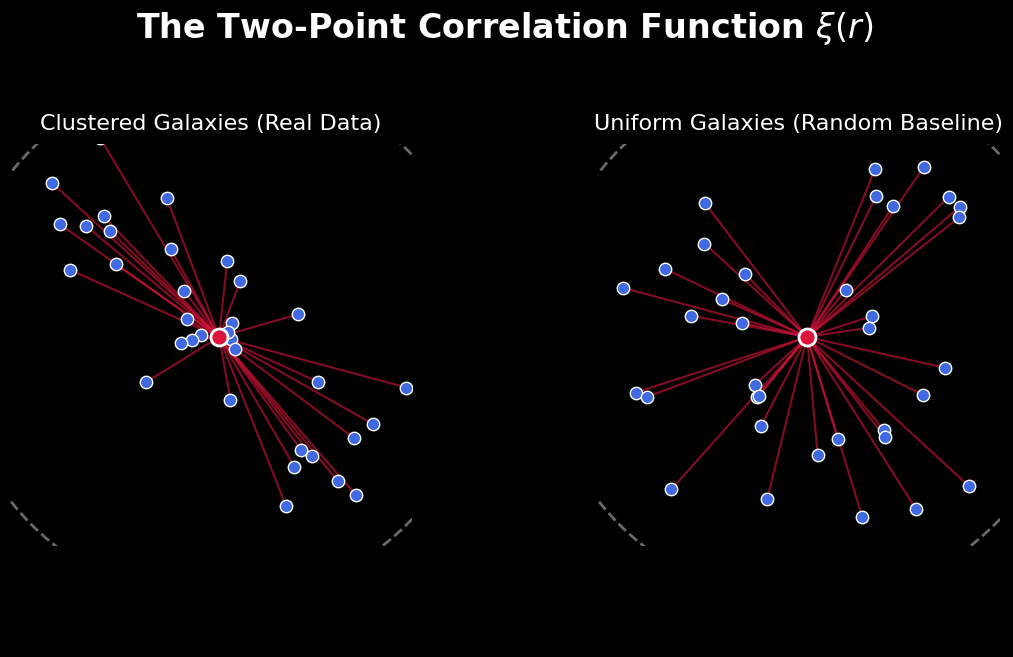

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import numpy as np

# --- 1. SET CLEAN, PROFESSIONAL FONT ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
fig.suptitle('The Two-Point Correlation Function $\\xi(r)$', fontsize=24, fontweight='bold', y=0.95)

np.random.seed(101)

# --- GENERATE DATA ---
# Clustered (Left)
x_c1, y_c1 = np.random.normal(5, 0.8, 15), np.random.normal(5, 0.8, 15)
x_c2, y_c2 = np.random.normal(2, 1.0, 10), np.random.normal(8, 1.0, 10)
x_c3, y_c3 = np.random.normal(8, 1.0, 10), np.random.normal(2, 1.0, 10)
x_clustered = np.concatenate([x_c1, x_c2, x_c3])
y_clustered = np.concatenate([y_c1, y_c2, y_c3])

# Random (Right)
n_total = len(x_clustered)
x_rand, y_rand = np.random.uniform(0.5, 9.5, n_total), np.random.uniform(0.5, 9.5, n_total)

target_x, target_y = 5.2, 5.2

# --- SETUP PLOTS ---
for ax, title in zip([ax1, ax2], ['Clustered Galaxies (Real Data)', 'Uniform Galaxies (Random Baseline)']):
    ax.set_title(title, fontsize=16, pad=10)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.axis('off')

# Plot background points and target galaxy
ax1.scatter(x_clustered, y_clustered, c='royalblue', s=80, zorder=2, edgecolors='white', linewidth=1)
ax2.scatter(x_rand, y_rand, c='royalblue', s=80, zorder=2, edgecolors='white', linewidth=1)
ax1.scatter(target_x, target_y, c='crimson', s=150, zorder=4, edgecolors='white', linewidth=2)
ax2.scatter(target_x, target_y, c='crimson', s=150, zorder=4, edgecolors='white', linewidth=2)

# Create empty circle patches and line lists
circle1 = patches.Circle((target_x, target_y), 0, fill=False, color='dimgrey', linestyle='--', linewidth=2, zorder=3)
circle2 = patches.Circle((target_x, target_y), 0, fill=False, color='dimgrey', linestyle='--', linewidth=2, zorder=3)
ax1.add_patch(circle1)
ax2.add_patch(circle2)

lines_clustered, lines_random = [], []

# Setup dynamic text box at the bottom
text_box = fig.text(0.5, 0.05, '', ha='center', fontsize=18, 
                    bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgrey', pad=10, boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.15, 1, 0.88])

# --- ANIMATION FUNCTION ---
def animate(frame):
    # Radius grows from 0 to 6
    r = frame * 0.15 
    
    # Update circles
    circle1.set_radius(r)
    circle2.set_radius(r)
    
    # Clear old lines
    for line in lines_clustered + lines_random:
        line.remove()
    lines_clustered.clear()
    lines_random.clear()
    
    # Draw new lines and count pairs
    dd_count = 0
    for x, y in zip(x_clustered, y_clustered):
        if 0.1 < np.sqrt((x - target_x)**2 + (y - target_y)**2) <= r:
            line, = ax1.plot([target_x, x], [target_y, y], color='crimson', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
            lines_clustered.append(line)
            dd_count += 1
            
    rr_count = 0
    for x, y in zip(x_rand, y_rand):
        if 0.1 < np.sqrt((x - target_x)**2 + (y - target_y)**2) <= r:
            line, = ax2.plot([target_x, x], [target_y, y], color='crimson', linestyle='-', linewidth=1.5, alpha=0.6, zorder=1)
            lines_random.append(line)
            rr_count += 1

    # Calculate correlation (handle division by zero)
    xi = (dd_count / rr_count) - 1 if rr_count > 0 else 0
    if r < 0.2: xi = 0 # Prevent early noise spike
    
    # Update text
    text_box.set_text(f"Search Radius r = {r:.1f}  |  Real Pairs = {dd_count}  |  Random Pairs = {rr_count}\n$\\xi(r) = {xi:.2f}$")
    
    return [circle1, circle2, text_box] + lines_clustered + lines_random

# Create animation (40 frames, 100ms per frame)
ani = animation.FuncAnimation(fig, animate, frames=45, interval=100, blit=True)

# Save as GIF
print("Generating GIF... This will take a few seconds.")
ani.save('slide_3_animation.gif', writer='pillow', fps=15)
print("Saved as slide_3_animation.gif!")

Generating dark-mode GIF... This will take a few seconds.
Saved as slide_3_animation_dark.gif!


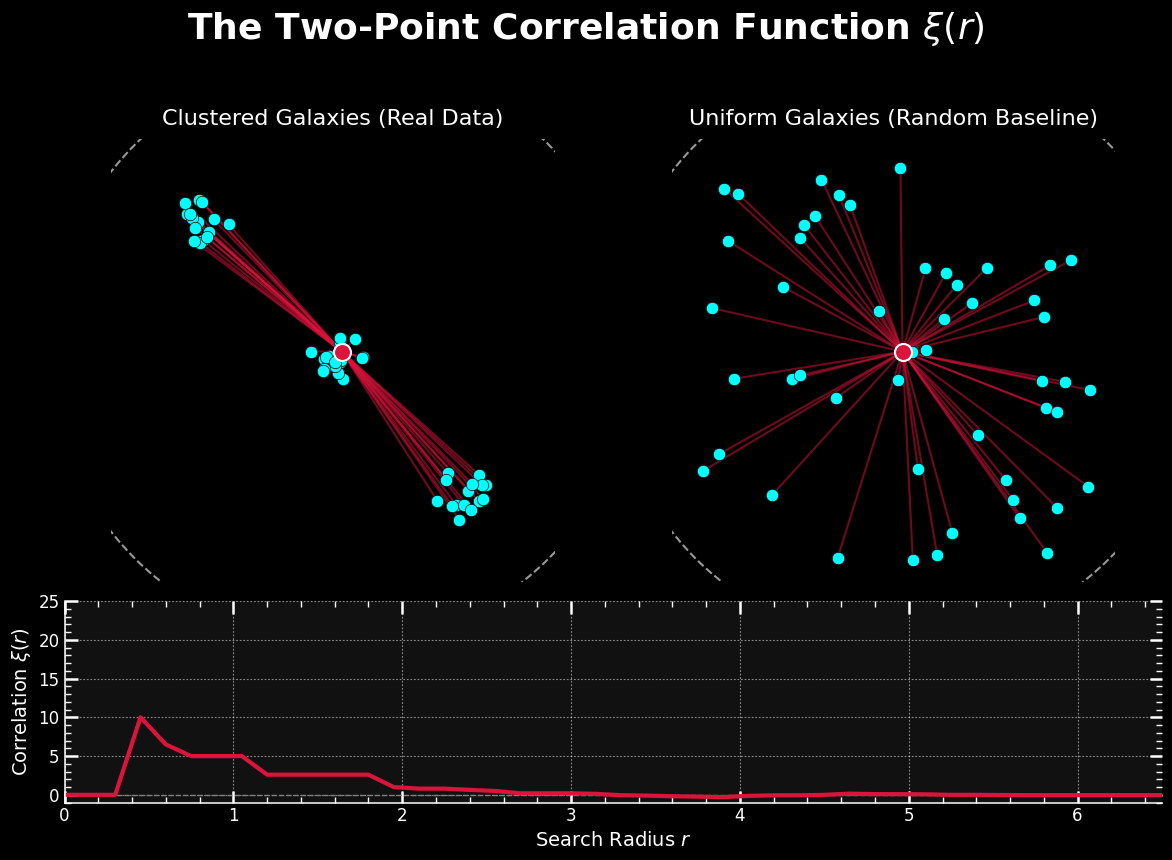

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import numpy as np
from matplotlib.gridspec import GridSpec

# --- 1. SET DARK MODE & FONTS ---
plt.style.use('dark_background') 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'

# Set up the figure with a taller height to fit the graph
fig = plt.figure(figsize=(12, 9), facecolor='black')

# Use GridSpec: Top row for the scatter plots (taller), Bottom row for the graph (shorter)
gs = GridSpec(2, 2, height_ratios=[2.2, 1], figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :]) 

fig.suptitle('The Two-Point Correlation Function $\\xi(r)$', fontsize=26, fontweight='bold', y=0.96, color='white')

np.random.seed(101)

# --- GENERATE DATA ---
# Clustered (Left)
# MODIFIED: Reduced the standard deviation (2nd parameter) for tighter clusters 
# and slightly increased the number of points (3rd parameter) so they stand out more.
x_c1, y_c1 = np.random.normal(5, 0.25, 20), np.random.normal(5, 0.25, 20)
x_c2, y_c2 = np.random.normal(2, 0.3, 15), np.random.normal(8, 0.3, 15)
x_c3, y_c3 = np.random.normal(8, 0.3, 15), np.random.normal(2, 0.3, 15)

x_clustered = np.concatenate([x_c1, x_c2, x_c3])
y_clustered = np.concatenate([y_c1, y_c2, y_c3])

# Random (Right)
n_total = len(x_clustered)
x_rand, y_rand = np.random.uniform(0.5, 9.5, n_total), np.random.uniform(0.5, 9.5, n_total)

target_x, target_y = 5.2, 5.2

# --- SETUP TOP ROW PLOTS ---
for ax, title in zip([ax1, ax2], ['Clustered Galaxies (Real Data)', 'Uniform Galaxies (Random Baseline)']):
    ax.set_title(title, fontsize=16, pad=10, color='white')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('black')

ax1.scatter(x_clustered, y_clustered, c='cyan', s=80, zorder=2, edgecolors='black', linewidth=0.5)
ax2.scatter(x_rand, y_rand, c='cyan', s=80, zorder=2, edgecolors='black', linewidth=0.5)
ax1.scatter(target_x, target_y, c='crimson', s=150, zorder=4, edgecolors='white', linewidth=1.5)
ax2.scatter(target_x, target_y, c='crimson', s=150, zorder=4, edgecolors='white', linewidth=1.5)

circle1 = patches.Circle((target_x, target_y), 0, fill=False, color='white', linestyle='--', linewidth=1.5, zorder=3, alpha=0.6)
circle2 = patches.Circle((target_x, target_y), 0, fill=False, color='white', linestyle='--', linewidth=1.5, zorder=3, alpha=0.6)
ax1.add_patch(circle1)
ax2.add_patch(circle2)

lines_clustered, lines_random = [], []

# --- SETUP BOTTOM GRAPH ---
ax3.set_facecolor('#111111')
ax3.set_xlim(0, 6.5)
# MODIFIED: Increased the y-axis limit to 25 because tighter clusters result in a much higher correlation spike
ax3.set_ylim(-1, 25) 
ax3.set_xlabel('Search Radius $r$', fontsize=14, color='white')
ax3.set_ylabel('Correlation $\\xi(r)$', fontsize=14, color='white')
ax3.tick_params(colors='white', labelsize=12)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

ax3.axhline(0, color='gray', linestyle='--', linewidth=1)

line_xi, = ax3.plot([], [], color='crimson', linewidth=3)

r_history, xi_history = [], []

text_box = fig.text(0.5, 0.38, '', ha='center', fontsize=16, color='white',
                    bbox=dict(facecolor='#222222', alpha=0.9, edgecolor='gray', pad=8, boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0, 1, 0.94])

# --- ANIMATION FUNCTION ---
def animate(frame):
    r = frame * 0.15 
    
    circle1.set_radius(r)
    circle2.set_radius(r)
    
    for line in lines_clustered + lines_random:
        line.remove()
    lines_clustered.clear()
    lines_random.clear()
    
    dd_count = 0
    for x, y in zip(x_clustered, y_clustered):
        if 0.1 < np.sqrt((x - target_x)**2 + (y - target_y)**2) <= r:
            line, = ax1.plot([target_x, x], [target_y, y], color='crimson', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
            lines_clustered.append(line)
            dd_count += 1
            
    rr_count = 0
    for x, y in zip(x_rand, y_rand):
        if 0.1 < np.sqrt((x - target_x)**2 + (y - target_y)**2) <= r:
            line, = ax2.plot([target_x, x], [target_y, y], color='crimson', linestyle='-', linewidth=1.5, alpha=0.5, zorder=1)
            lines_random.append(line)
            rr_count += 1

    if rr_count == 0:
        xi = 0
    else:
        xi = (dd_count / rr_count) - 1

    r_history.append(r)
    
    # MODIFIED: Adjusted the visual cap for the graph to match the new y-axis limits
    xi_graph = min(xi, 25) if r > 0.3 else 0 
    xi_history.append(xi_graph)
    
    line_xi.set_data(r_history, xi_history)
    
    text_box.set_text(f"Search Radius r = {r:.1f}  |  Real Pairs = {dd_count}  |  Random Pairs = {rr_count}  |  $\\xi(r) = {xi:.2f}$")
    
    return [circle1, circle2, text_box, line_xi] + lines_clustered + lines_random

# Create animation (45 frames)
ani = animation.FuncAnimation(fig, animate, frames=45, interval=150, blit=True)

# Save as GIF
print("Generating dark-mode GIF... This will take a few seconds.")
ani.save('slide_3_animation_dark.gif', writer='pillow', fps=15)
print("Saved as slide_3_animation_dark.gif!")

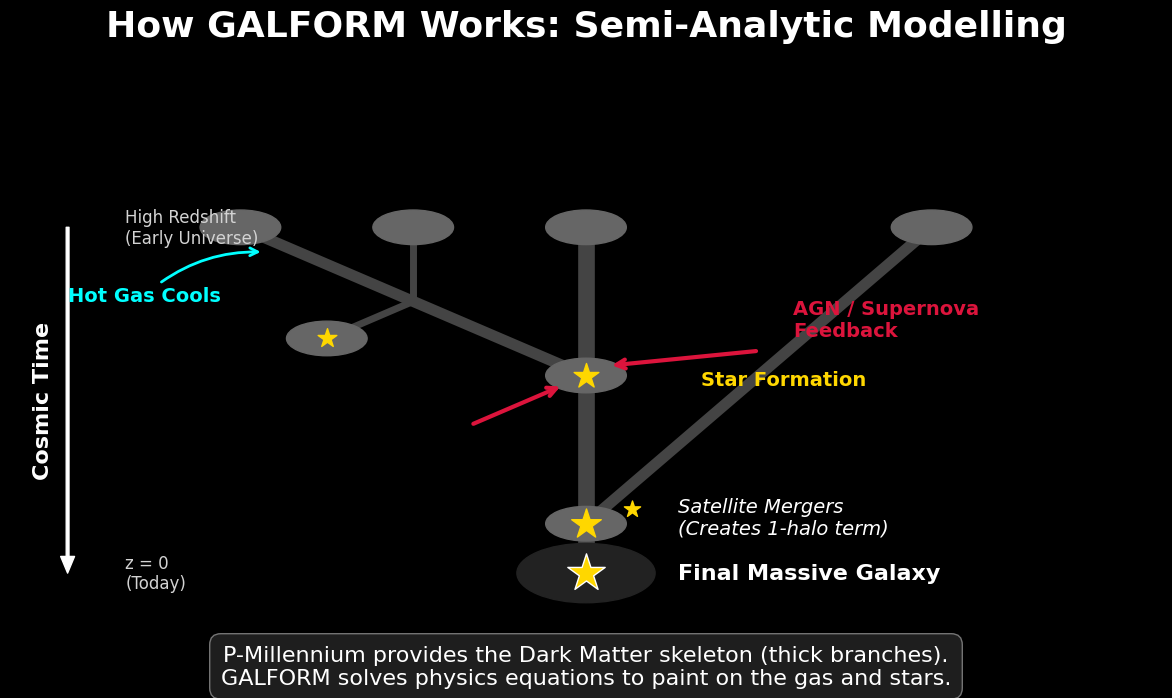

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

# --- 1. SET DARK MODE & FONTS ---
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Set up the figure for a presentation (wide aspect ratio)
fig, ax = plt.subplots(figsize=(12, 7.5), facecolor='black')
ax.set_facecolor('black')

fig.suptitle('How GALFORM Works: Semi-Analytic Modelling', fontsize=26, fontweight='bold', y=0.95, color='white')

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# --- 2. DRAW THE DARK MATTER MERGER TREE (The Skeleton) ---
# Main Trunk
ax.plot([5, 5], [8, 1], color='#444444', linewidth=12, zorder=1, solid_capstyle='round')

# Left Branch (Merges early)
ax.plot([2, 5], [8, 5], color='#444444', linewidth=8, zorder=1, solid_capstyle='round')

# Right Branch (Merges late)
ax.plot([8, 5], [8, 2], color='#444444', linewidth=8, zorder=1, solid_capstyle='round')

# Inner sub-branch on the left
ax.plot([3.5, 3.5], [8, 6.5], color='#444444', linewidth=5, zorder=1, solid_capstyle='round')
ax.plot([3.5, 2.75], [6.5, 5.75], color='#444444', linewidth=5, zorder=1, solid_capstyle='round')

# Add "Time" arrow on the left
ax.annotate('', xy=(0.5, 1), xytext=(0.5, 8),
            arrowprops=dict(facecolor='white', edgecolor='white', width=2, headwidth=10))
ax.text(0.2, 4.5, 'Cosmic Time', color='white', fontsize=16, rotation=90, va='center', fontweight='bold')
ax.text(1.0, 8, 'High Redshift\n(Early Universe)', color='lightgrey', fontsize=12, va='center')
ax.text(1.0, 1, 'z = 0\n(Today)', color='lightgrey', fontsize=12, va='center')


# --- 3. ADD BARYONIC PHYSICS (GALFORM's Job) ---

# Halo nodes (Grey circles)
halos = [(5,8), (2,8), (8,8), (3.5,8), (2.75, 5.75), (5,5), (5,2), (5,1)]
for hx, hy in halos:
    ax.add_patch(patches.Circle((hx, hy), 0.35, color='#666666', zorder=2))

# Gas Cooling (Cyan arrows pointing inward to halos)
ax.annotate('Hot Gas Cools', xy=(2.2, 7.5), xytext=(0.5, 6.5), color='cyan', fontsize=14, fontweight='bold',
            arrowprops=dict(arrowstyle="->", color='cyan', lw=2, connectionstyle="arc3,rad=-0.2"))

# Star Formation (Gold stars inside the nodes)
ax.scatter(2.75, 5.75, marker='*', color='gold', s=200, zorder=4)
ax.scatter(5, 5, marker='*', color='gold', s=350, zorder=4)
ax.text(6, 4.8, 'Star Formation', color='gold', fontsize=14, fontweight='bold')

# Feedback / Supernovae (Red explosive arrows pointing OUT)
ax.annotate('', xy=(6.5, 5.5), xytext=(5.2, 5.2), arrowprops=dict(arrowstyle="<-", color='crimson', lw=3))
ax.annotate('', xy=(4, 4), xytext=(4.8, 4.8), arrowprops=dict(arrowstyle="<-", color='crimson', lw=3))
ax.text(6.8, 5.8, 'AGN / Supernova\nFeedback', color='crimson', fontsize=14, fontweight='bold', ha='left')

# Satellite Mergers (where right branch meets the trunk)
ax.scatter(5, 2, marker='*', color='gold', s=500, zorder=4) # Central galaxy
ax.scatter(5.4, 2.3, marker='*', color='gold', s=150, zorder=4) # Satellite galaxy spiraling in
ax.text(5.8, 1.8, 'Satellite Mergers\n(Creates 1-halo term)', color='white', fontsize=14, style='italic')

# Final Present-Day Galaxy
ax.add_patch(patches.Circle((5, 1), 0.6, color='#222222', zorder=2)) # Big final halo
ax.scatter(5, 1, marker='*', color='gold', s=800, zorder=4, edgecolors='white', linewidth=1)
ax.text(5.8, 1, 'Final Massive Galaxy', color='white', fontsize=16, fontweight='bold', va='center')


# --- 4. EXPLANATORY TEXT BOX ---
explanation = (
    "P-Millennium provides the Dark Matter skeleton (thick branches).\n"
    "GALFORM solves physics equations to paint on the gas and stars."
)
fig.text(0.5, 0.05, explanation, ha='center', fontsize=16, color='white',
         bbox=dict(facecolor='#222222', alpha=0.9, edgecolor='gray', pad=10, boxstyle='round,pad=0.5'))

# Format layout
plt.tight_layout(rect=[0, 0.1, 1, 0.90])

# Save figure
plt.savefig('slide_5_galform_tree.png', dpi=300, bbox_inches='tight')
plt.show()

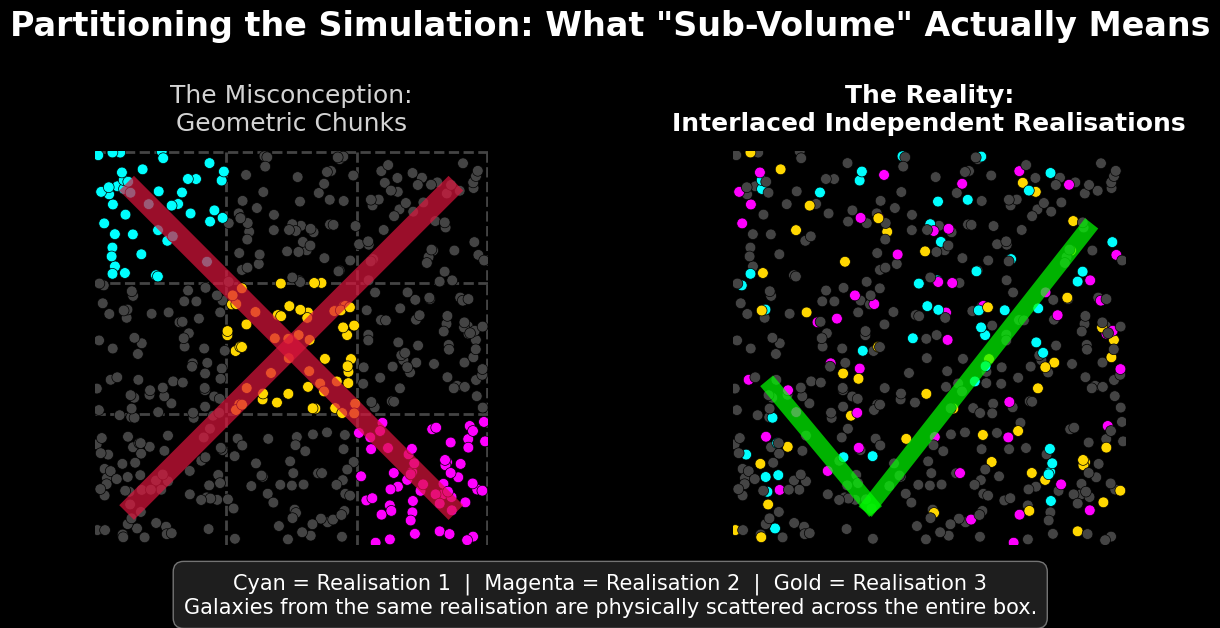

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET DARK MODE & FONTS ---
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5), facecolor='black')
fig.suptitle('Partitioning the Simulation: What "Sub-Volume" Actually Means', 
             fontsize=24, fontweight='bold', y=0.98, color='white')

# Generate a base distribution of galaxies (slightly clustered)
np.random.seed(42)
x_base = np.random.uniform(0, 10, 500)
y_base = np.random.uniform(0, 10, 500)

# --- LEFT PANEL: The Misconception (Geometric Chunks) ---
ax1.set_title('The Misconception:\nGeometric Chunks', fontsize=18, pad=15, color='lightgrey')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')
ax1.axis('off')

# Draw grid lines to emphasize "chunks"
for i in range(1, 4):
    ax1.axhline(i * 3.33, color='#444444', linestyle='--', linewidth=2, zorder=1)
    ax1.axvline(i * 3.33, color='#444444', linestyle='--', linewidth=2, zorder=1)

# Color points based on their spatial grid location
colors_left = []
for x, y in zip(x_base, y_base):
    if x < 3.33 and y > 6.66:
        colors_left.append('cyan')       # "Chunk 1"
    elif x > 6.66 and y < 3.33:
        colors_left.append('magenta')    # "Chunk 2"
    elif 3.33 < x < 6.66 and 3.33 < y < 6.66:
        colors_left.append('gold')       # "Chunk 3"
    else:
        colors_left.append('#444444')    # Other chunks

ax1.scatter(x_base, y_base, c=colors_left, s=60, zorder=2, edgecolors='black', linewidth=0.5)

# Add a massive, semi-transparent Red 'X' to show this is WRONG
ax1.plot([1, 9], [1, 9], color='crimson', linewidth=15, alpha=0.7, zorder=5)
ax1.plot([1, 9], [9, 1], color='crimson', linewidth=15, alpha=0.7, zorder=5)


# --- RIGHT PANEL: The Reality (Interlaced Realisations) ---
ax2.set_title('The Reality:\nInterlaced Independent Realisations', fontsize=18, pad=15, color='white', fontweight='bold')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')

# Shuffle the array to randomly assign "sub-volume" IDs regardless of physical space
shuffled_indices = np.random.permutation(500)
colors_right = ['#444444'] * 500  # Default grey

# Assign 10% of galaxies to Realisation 1, 2, and 3
for i in range(50):
    colors_right[shuffled_indices[i]] = 'cyan'           # Realisation 1
    colors_right[shuffled_indices[i + 50]] = 'magenta'   # Realisation 2
    colors_right[shuffled_indices[i + 100]] = 'gold'     # Realisation 3

ax2.scatter(x_base, y_base, c=colors_right, s=60, zorder=2, edgecolors='black', linewidth=0.5)

# Add a green checkmark to show this is CORRECT
ax2.plot([1, 3.5], [4, 1], color='#00FF00', linewidth=12, alpha=0.7, zorder=5)
ax2.plot([3.5, 9], [1, 8], color='#00FF00', linewidth=12, alpha=0.7, zorder=5)

# --- EXPLANATORY LEGEND/TEXT ---
legend_text = (
    "Cyan = Realisation 1  |  Magenta = Realisation 2  |  Gold = Realisation 3\n"
    "Galaxies from the same realisation are physically scattered across the entire box."
)
fig.text(0.5, 0.05, legend_text, ha='center', fontsize=15, color='white',
         bbox=dict(facecolor='#222222', alpha=0.9, edgecolor='gray', pad=10, boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.savefig('slide_6_independent_realisations.png', dpi=300, bbox_inches='tight')
plt.show()

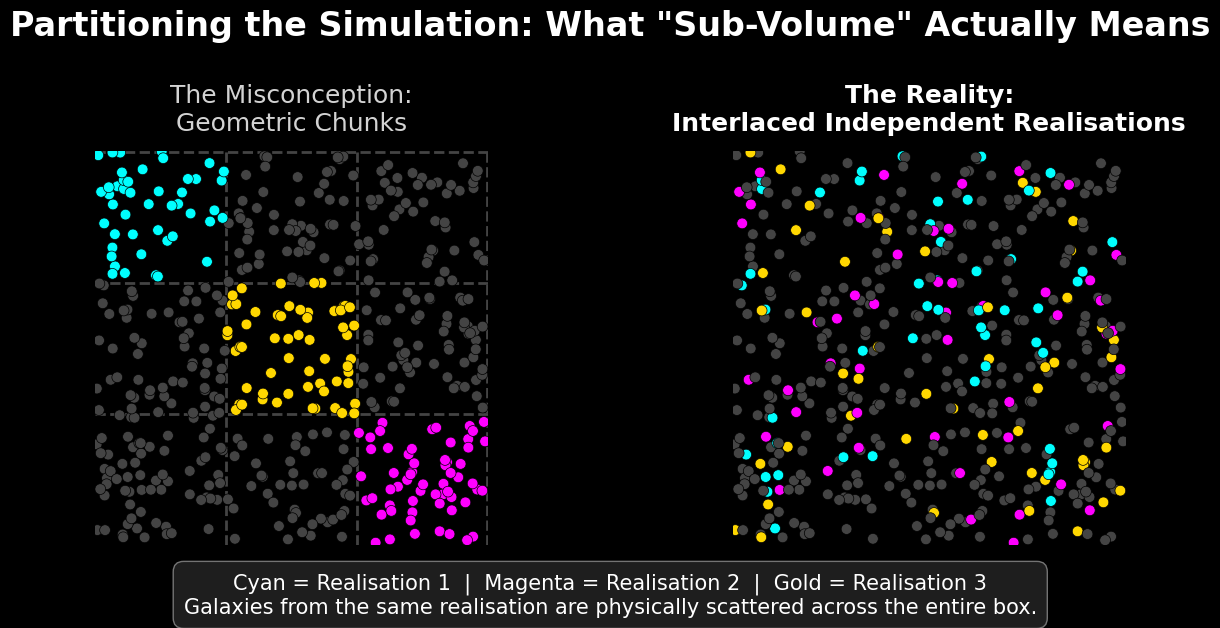

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET DARK MODE & FONTS ---
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5), facecolor='black')
fig.suptitle('Partitioning the Simulation: What "Sub-Volume" Actually Means', 
             fontsize=24, fontweight='bold', y=0.98, color='white')

# Generate a base distribution of galaxies (slightly clustered)
np.random.seed(42)
x_base = np.random.uniform(0, 10, 500)
y_base = np.random.uniform(0, 10, 500)

# --- LEFT PANEL: The Misconception (Geometric Chunks) ---
ax1.set_title('The Misconception:\nGeometric Chunks', fontsize=18, pad=15, color='lightgrey')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_aspect('equal')
ax1.axis('off')

# Draw grid lines to emphasize "chunks"
for i in range(1, 4):
    ax1.axhline(i * 3.33, color='#444444', linestyle='--', linewidth=2, zorder=1)
    ax1.axvline(i * 3.33, color='#444444', linestyle='--', linewidth=2, zorder=1)

# Color points based on their spatial grid location
colors_left = []
for x, y in zip(x_base, y_base):
    if x < 3.33 and y > 6.66:
        colors_left.append('cyan')       # "Chunk 1"
    elif x > 6.66 and y < 3.33:
        colors_left.append('magenta')    # "Chunk 2"
    elif 3.33 < x < 6.66 and 3.33 < y < 6.66:
        colors_left.append('gold')       # "Chunk 3"
    else:
        colors_left.append('#444444')    # Other chunks

ax1.scatter(x_base, y_base, c=colors_left, s=60, zorder=2, edgecolors='black', linewidth=0.5)


# --- RIGHT PANEL: The Reality (Interlaced Realisations) ---
ax2.set_title('The Reality:\nInterlaced Independent Realisations', fontsize=18, pad=15, color='white', fontweight='bold')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_aspect('equal')
ax2.axis('off')

# Shuffle the array to randomly assign "sub-volume" IDs regardless of physical space
shuffled_indices = np.random.permutation(500)
colors_right = ['#444444'] * 500  # Default grey

# Assign 10% of galaxies to Realisation 1, 2, and 3
for i in range(50):
    colors_right[shuffled_indices[i]] = 'cyan'           # Realisation 1
    colors_right[shuffled_indices[i + 50]] = 'magenta'   # Realisation 2
    colors_right[shuffled_indices[i + 100]] = 'gold'     # Realisation 3

ax2.scatter(x_base, y_base, c=colors_right, s=60, zorder=2, edgecolors='black', linewidth=0.5)


# --- EXPLANATORY LEGEND/TEXT ---
legend_text = (
    "Cyan = Realisation 1  |  Magenta = Realisation 2  |  Gold = Realisation 3\n"
    "Galaxies from the same realisation are physically scattered across the entire box."
)
fig.text(0.5, 0.05, legend_text, ha='center', fontsize=15, color='white',
         bbox=dict(facecolor='#222222', alpha=0.9, edgecolor='gray', pad=10, boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.savefig('slide_6_independent_realisations.png', dpi=300, bbox_inches='tight')
plt.show()

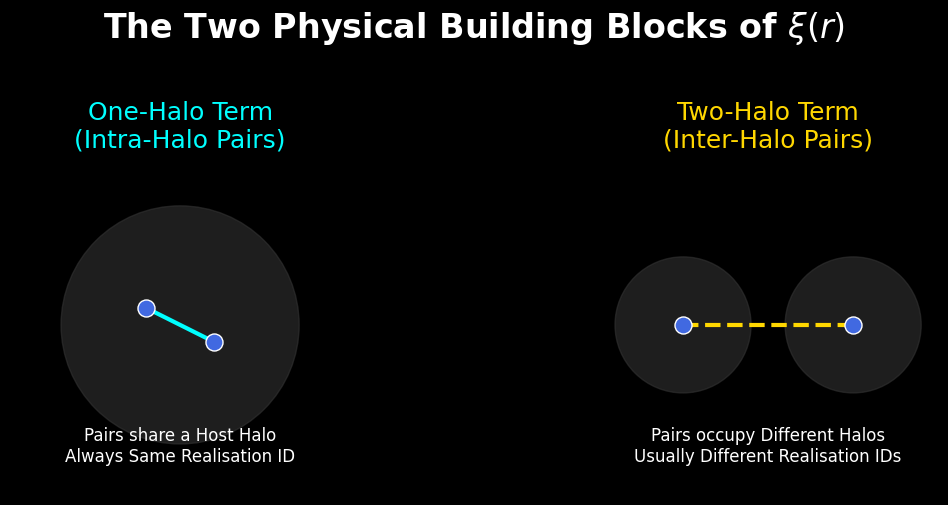

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- SET DARK MODE & FONTS ---
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='black')
fig.suptitle('The Two Physical Building Blocks of $\\xi(r)$', fontsize=24, fontweight='bold', y=0.95)

# --- LEFT: One-Halo Term ---
ax1.set_title('One-Halo Term\n(Intra-Halo Pairs)', fontsize=18, color='cyan')
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10); ax1.set_aspect('equal'); ax1.axis('off')

# Single Halo
halo = patches.Circle((5, 5), 3.5, color='#333333', alpha=0.6, zorder=1)
ax1.add_patch(halo)

# Two galaxies in the SAME halo
ax1.scatter([4, 6], [5.5, 4.5], c='royalblue', s=150, zorder=3, edgecolors='white')
ax1.plot([4, 6], [5.5, 4.5], color='cyan', linewidth=3, zorder=2)

ax1.text(5, 1, "Pairs share a Host Halo\nAlways Same Realisation ID", ha='center', fontsize=12)

# --- RIGHT: Two-Halo Term ---
ax2.set_title('Two-Halo Term\n(Inter-Halo Pairs)', fontsize=18, color='gold')
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.set_aspect('equal'); ax2.axis('off')

# Two separate halos
halo_a = patches.Circle((2.5, 5), 2, color='#333333', alpha=0.6, zorder=1)
halo_b = patches.Circle((7.5, 5), 2, color='#333333', alpha=0.6, zorder=1)
ax2.add_patch(halo_a); ax2.add_patch(halo_b)

# Two galaxies in DIFFERENT halos
ax2.scatter([2.5, 7.5], [5, 5], c='royalblue', s=150, zorder=3, edgecolors='white')
ax2.plot([2.5, 7.5], [5, 5], color='gold', linestyle='--', linewidth=3, zorder=2)

ax2.text(5, 1, "Pairs occupy Different Halos\nUsually Different Realisation IDs", ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.9])
plt.savefig('slide_7_one_two_halo.png', dpi=300)
plt.show()

Generating the LARGE 3-Halo GIF... This will take a few seconds.
Saved as slide_7_three_halos_large.gif!


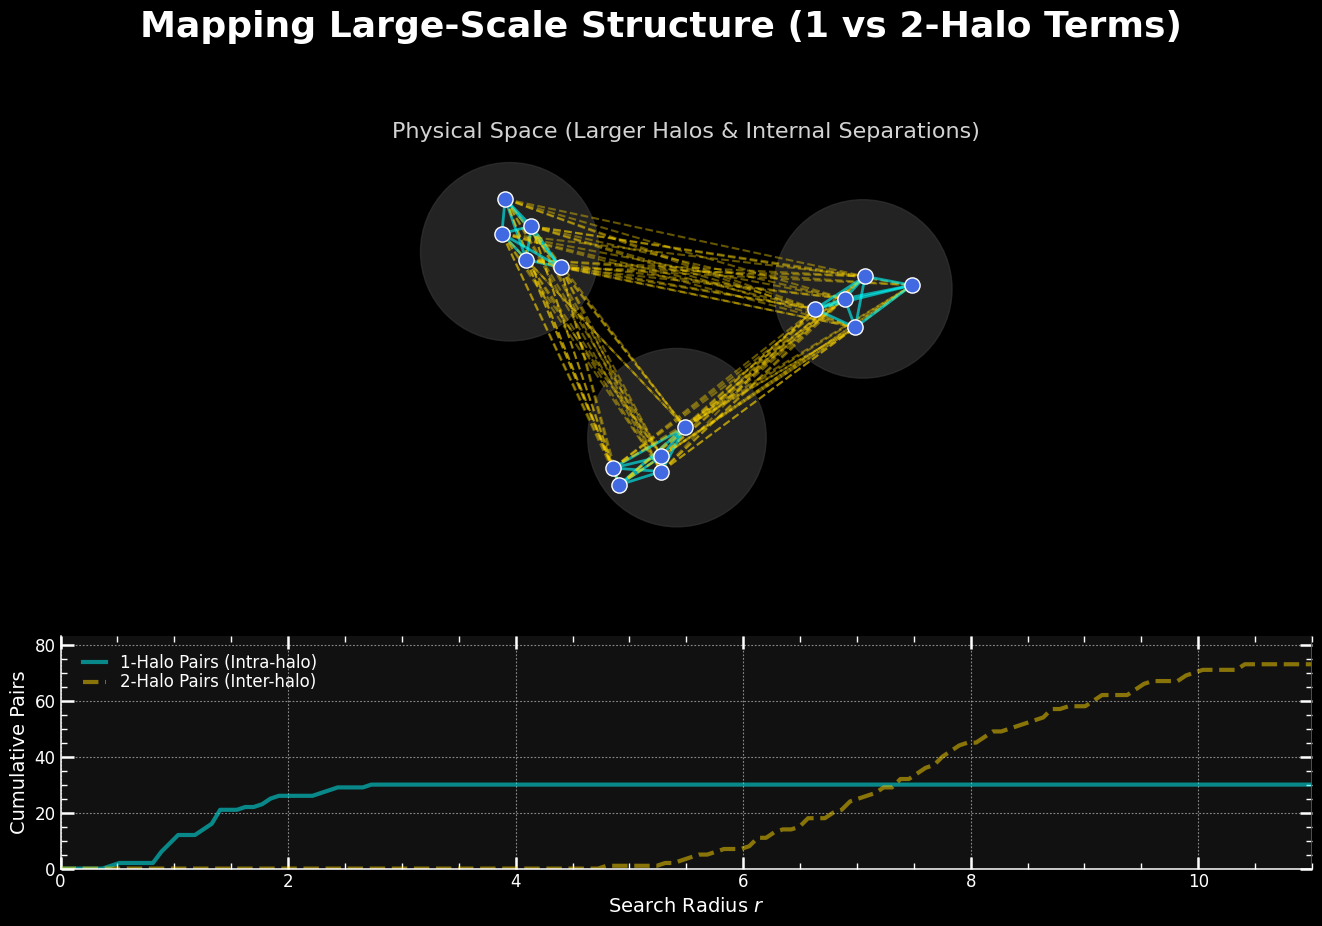

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import numpy as np
from matplotlib.gridspec import GridSpec

# --- 1. SET DARK MODE & FONTS ---
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Set up a wider figure
fig = plt.figure(figsize=(13.5, 10), facecolor='black')
gs = GridSpec(2, 1, height_ratios=[1.6, 1], figure=fig)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

fig.suptitle('Mapping Large-Scale Structure (1 vs 2-Halo Terms)', fontsize=26, fontweight='bold', y=0.95, color='white')

# --- 2. GENERATE GALAXIES (BIGGER INTERNAL GAPS) ---
np.random.seed(42)

# Standard deviation increased from 0.35 to 0.90 to spread galaxies out
spread = 0.90
xA, yA = np.random.normal(2.0, spread, 5), np.random.normal(7.5, spread, 5)    # Halo A
xB, yB = np.random.normal(6.5, spread, 5), np.random.normal(2.5, spread, 5)    # Halo B
xC, yC = np.random.normal(11.5, spread, 5), np.random.normal(6.5, spread, 5)   # Halo C

x_all = np.concatenate([xA, xB, xC])
y_all = np.concatenate([yA, yB, yC])
halo_ids = np.concatenate([np.zeros(5), np.ones(5), np.full(5, 2)])
n_gal = len(x_all)

# --- 3. PRE-CALCULATE ALL PAIRS ---
pairs = []
for i in range(n_gal):
    for j in range(i + 1, n_gal):
        dist = np.sqrt((x_all[i] - x_all[j])**2 + (y_all[i] - y_all[j])**2)
        is_1halo = (halo_ids[i] == halo_ids[j])
        pairs.append({'dist': dist, 'i': i, 'j': j, 'is_1halo': is_1halo})

# --- 4. SETUP TOP PANEL (THE MAP) ---
ax1.set_title('Physical Space (Larger Halos & Internal Separations)', fontsize=16, color='lightgrey', pad=15)
ax1.set_xlim(-0.5, 14.0)
ax1.set_ylim(0.0, 10.0)
ax1.set_aspect('equal')
ax1.axis('off')

# Draw Halos (Radius increased from 1.3 to 2.4)
halo_radius = 2.4
ax1.add_patch(patches.Circle((2.0, 7.5), halo_radius, color='#333333', alpha=0.7, zorder=1))
ax1.add_patch(patches.Circle((6.5, 2.5), halo_radius, color='#333333', alpha=0.7, zorder=1))
ax1.add_patch(patches.Circle((11.5, 6.5), halo_radius, color='#333333', alpha=0.7, zorder=1))

# Draw Galaxies
ax1.scatter(x_all, y_all, c='royalblue', s=120, zorder=4, edgecolors='white', linewidth=1)

# Position text box safely BETWEEN the two plots
count_text = fig.text(0.5, 0.43, '', ha='center', va='center', fontsize=16, color='white',
                      bbox=dict(facecolor='#222222', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.6'))

# --- 5. SETUP BOTTOM PANEL (THE GRAPH) ---
max_r = 11.0 # Slightly increased to ensure we catch all 2-halo pairs
r_vals = np.linspace(0, max_r, 150)
count_1h = [sum(1 for p in pairs if p['is_1halo'] and p['dist'] <= r) for r in r_vals]
count_2h = [sum(1 for p in pairs if not p['is_1halo'] and p['dist'] <= r) for r in r_vals]

ax2.set_facecolor('#111111')
ax2.set_xlim(0, max_r)
ax2.set_ylim(0, max(max(count_1h), max(count_2h)) + 10)
ax2.set_xlabel('Search Radius $r$', fontsize=14, color='white')
ax2.set_ylabel('Cumulative Pairs', fontsize=14, color='white')
ax2.tick_params(colors='white', labelsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Plot the static background curves
ax2.plot(r_vals, count_1h, color='cyan', linewidth=3, label='1-Halo Pairs (Intra-halo)', alpha=0.5)
ax2.plot(r_vals, count_2h, color='gold', linewidth=3, linestyle='--', label='2-Halo Pairs (Inter-halo)', alpha=0.5)
ax2.legend(loc='upper left', fontsize=12, facecolor='black', edgecolor='gray', labelcolor='white')

# The moving vertical bar
v_bar = ax2.axvline(x=0, color='crimson', linewidth=2, linestyle='-')

# Adjust layout
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.subplots_adjust(hspace=0.35) 

# --- 6. ANIMATION LOOP ---
drawn_lines = []

def animate(frame):
    current_r = min(frame * (max_r / 120), max_r) 
    
    for line in drawn_lines:
        line.remove()
    drawn_lines.clear()
    
    n_1h = 0
    n_2h = 0
    
    for p in pairs:
        if p['dist'] <= current_r:
            xi, xj = x_all[p['i']], x_all[p['j']]
            yi, yj = y_all[p['i']], y_all[p['j']]
            
            if p['is_1halo']:
                n_1h += 1
                line, = ax1.plot([xi, xj], [yi, yj], color='cyan', linewidth=2, alpha=0.6, zorder=2)
            else:
                n_2h += 1
                line, = ax1.plot([xi, xj], [yi, yj], color='gold', linewidth=1.5, linestyle='--', alpha=0.4, zorder=2)
            drawn_lines.append(line)
            
    v_bar.set_xdata([current_r, current_r])
    count_text.set_text(f"  Current Radius $r$ = {current_r:.1f}   |   1-Halo Pairs: {n_1h}   |   2-Halo Pairs: {n_2h}  ")
    
    return [v_bar, count_text] + drawn_lines

total_frames = 140 
ani = animation.FuncAnimation(fig, animate, frames=total_frames, interval=150, blit=True)

print("Generating the LARGE 3-Halo GIF... This will take a few seconds.")
ani.save('slide_7_three_halos_large.gif', writer='pillow', fps=12) 
print("Saved as slide_7_three_halos_large.gif!")

In [ ]:
# Animated 3D visualization: evolving pair links and paired-counts
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation
from matplotlib.gridspec import GridSpec

# --- Prepare 3D positions (self-contained) ---
np.random.seed(42)
spread = 0.90
# Halo centres
halo_centres = [(2.0, 7.5, 5.0), (6.5, 2.5, 3.0), (11.5, 6.5, 6.5)]
# Generate galaxies around centres
xA, yA, zA = np.random.normal(2.0, spread, 5), np.random.normal(7.5, spread, 5), np.random.normal(5.0, spread, 5)
xB, yB, zB = np.random.normal(6.5, spread, 5), np.random.normal(2.5, spread, 5), np.random.normal(3.0, spread, 5)
xC, yC, zC = np.random.normal(11.5, spread, 5), np.random.normal(6.5, spread, 5), np.random.normal(6.5, spread, 5)

x_all = np.concatenate([xA, xB, xC])
y_all = np.concatenate([yA, yB, yC])
z_all = np.concatenate([zA, zB, zC])
halo_ids = np.concatenate([np.zeros(5), np.ones(5), np.full(5, 2)])

n_gal = len(x_all)

# Precompute 3D pair distances and 1/2-halo flags
pairs = []
for i in range(n_gal):
    for j in range(i + 1, n_gal):
        dist = np.sqrt((x_all[i] - x_all[j])**2 + (y_all[i] - y_all[j])**2 + (z_all[i] - z_all[j])**2)
        is_1halo = (halo_ids[i] == halo_ids[j])
        pairs.append({'dist': dist, 'i': i, 'j': j, 'is_1halo': is_1halo})

# Cumulative counts for the bottom plot
max_r = 11.0
r_vals = np.linspace(0, max_r, 150)
count_1h = [sum(1 for p in pairs if p['is_1halo'] and p['dist'] <= r) for r in r_vals]
count_2h = [sum(1 for p in pairs if not p['is_1halo'] and p['dist'] <= r) for r in r_vals]

# --- Figure layout ---
fig = plt.figure(figsize=(12, 9), facecolor='black')
gs = GridSpec(2, 1, height_ratios=[1.6, 1], figure=fig)
ax3 = fig.add_subplot(gs[0], projection='3d', facecolor='#000000')
ax2 = fig.add_subplot(gs[1], facecolor='#111111')

# Draw translucent halo spheres
halo_radius = 2.4
u = np.linspace(0, 2 * np.pi, 36)
v = np.linspace(0, np.pi, 18)
for (cx, cy, cz) in halo_centres:
    X = cx + halo_radius * np.outer(np.cos(u), np.sin(v))
    Y = cy + halo_radius * np.outer(np.sin(u), np.sin(v))
    Z = cz + halo_radius * np.outer(np.ones_like(u), np.cos(v))
    ax3.plot_surface(X, Y, Z, color='#444444', alpha=0.12, linewidth=0, rstride=1, cstride=1)

# Plot galaxies (fixed)
colors = ['royalblue' if hid == 0 else 'lime' if hid == 1 else 'gold' for hid in halo_ids]
scat = ax3.scatter(x_all, y_all, z_all, c=colors, s=90, edgecolors='white', linewidth=0.6, depthshade=True)

ax3.set_xlim(-0.5, 14.0)
ax3.set_ylim(0.0, 10.0)
ax3.set_zlim(0.0, 10.0)
ax3.set_xlabel('X', color='white')
ax3.set_ylabel('Y', color='white')
ax3.set_zlabel('Z', color='white')
ax3.tick_params(colors='white')
ax3.view_init(elev=25, azim=30)

# Bottom panel styling
ax2.set_xlim(0, max_r)
ax2.set_ylim(0, max(max(count_1h), max(count_2h)) + 10)
ax2.set_xlabel('Search Radius $r$', fontsize=12, color='white')
ax2.set_ylabel('Cumulative Pairs', fontsize=12, color='white')
ax2.plot(r_vals, count_1h, color='cyan', linewidth=3, label='1-Halo Pairs (Intra-halo)', alpha=0.5)
ax2.plot(r_vals, count_2h, color='gold', linewidth=3, linestyle='--', label='2-Halo Pairs (Inter-halo)', alpha=0.5)
ax2.legend(loc='upper left', fontsize=10, facecolor='black', edgecolor='gray')
ax2.tick_params(colors='white')

v_bar = ax2.axvline(x=0, color='crimson', linewidth=2)
count_text = fig.text(0.5, 0.43, '', ha='center', va='center', fontsize=12, color='white',
                      bbox=dict(facecolor='#222222', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.6'))

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.subplots_adjust(hspace=0.35)

# --- Animation ---
drawn_lines = []

def animate(frame):
    current_r = min(frame * (max_r / total_frames), max_r)

    # remove old lines
    while drawn_lines:
        ln = drawn_lines.pop()
        try:
            ln.remove()
        except Exception:
            pass

    n_1h = 0
    n_2h = 0
    for p in pairs:
        if p['dist'] <= current_r:
            i, j = p['i'], p['j']
            xi, xj = x_all[i], x_all[j]
            yi, yj = y_all[i], y_all[j]
            zi, zj = z_all[i], z_all[j]
            if p['is_1halo']:
                n_1h += 1
                ln, = ax3.plot([xi, xj], [yi, yj], [zi, zj], color='cyan', linewidth=2, alpha=0.6)
            else:
                n_2h += 1
                ln, = ax3.plot([xi, xj], [yi, yj], [zi, zj], color='gold', linewidth=1.5, linestyle='--', alpha=0.4)
            drawn_lines.append(ln)

    v_bar.set_xdata([current_r, current_r])
    count_text.set_text(f"  Current Radius $r$ = {current_r:.1f}   |   1-Halo Pairs: {n_1h}   |   2-Halo Pairs: {n_2h}  ")

    # optional: slowly rotate the 3D view
    az = 30 + frame * 0.6
    ax3.view_init(elev=25, azim=az)

    return drawn_lines + [v_bar, count_text]

total_frames = 140
ani = animation.FuncAnimation(fig, animate, frames=total_frames, interval=120, blit=False)

print('Generating 3D animated GIF... this may take a while.')
ani.save('slide_7_three_halos_3d_anim.gif', writer='pillow', fps=12)
print('Saved slide_7_three_halos_3d_anim.gif')


Saved 3D visualization to slide_7_three_halos_3d.png


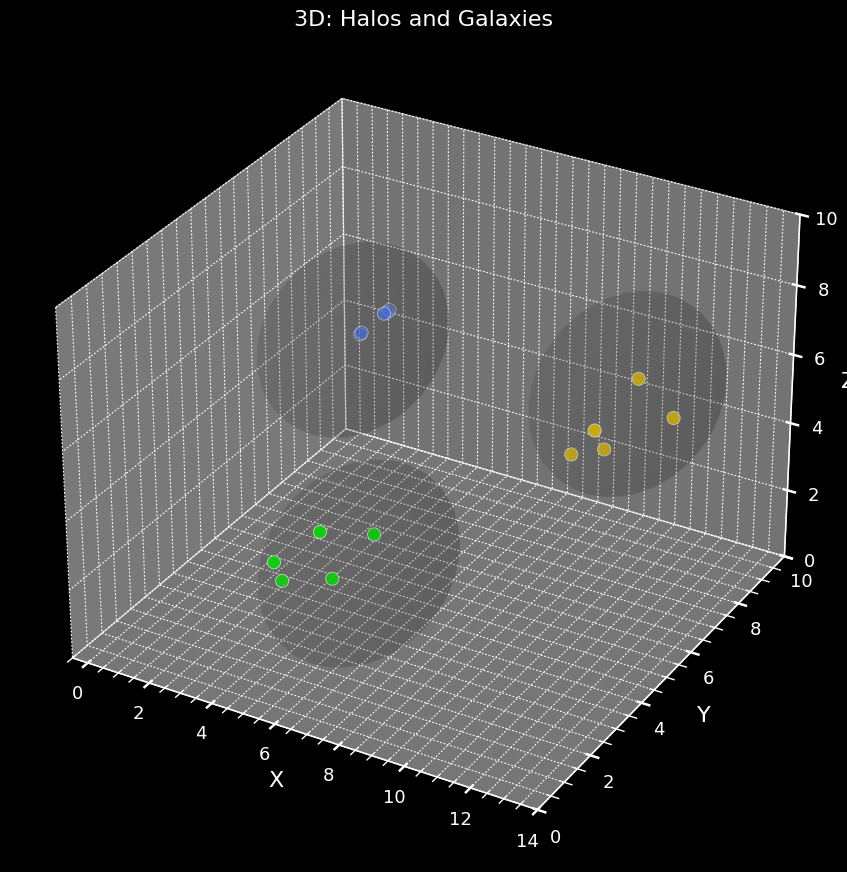

In [18]:
# 3D visualization: Halos as translucent spheres, galaxies as points
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Reuse the 2D clusters' x/y positions and generate z positions
np.random.seed(42)
spread = 0.90
zA = np.random.normal(5.0, spread, 5)
zB = np.random.normal(3.0, spread, 5)
zC = np.random.normal(6.5, spread, 5)

x_all_3d = np.concatenate([xA, xB, xC])
y_all_3d = np.concatenate([yA, yB, yC])
z_all = np.concatenate([zA, zB, zC])

# Setup figure with dark background
fig = plt.figure(figsize=(10, 9), facecolor='black')
ax3 = fig.add_subplot(111, projection='3d', facecolor='#000000')

# Halo centres and radius
halo_centres = [(2.0, 7.5, 5.0), (6.5, 2.5, 3.0), (11.5, 6.5, 6.5)]
halo_radius = 2.4

# Utility: plot translucent sphere
u = np.linspace(0, 2 * np.pi, 36)
v = np.linspace(0, np.pi, 18)
for (cx, cy, cz) in halo_centres:
    X = cx + halo_radius * np.outer(np.cos(u), np.sin(v))
    Y = cy + halo_radius * np.outer(np.sin(u), np.sin(v))
    Z = cz + halo_radius * np.outer(np.ones_like(u), np.cos(v))
    ax3.plot_surface(X, Y, Z, color='#444444', alpha=0.12, linewidth=0, rstride=1, cstride=1)

# Colour galaxies by halo id
colors = ['royalblue' if hid == 0 else 'lime' if hid == 1 else 'gold' for hid in halo_ids]
ax3.scatter(x_all_3d, y_all_3d, z_all, c=colors, s=90, edgecolors='white', linewidth=0.6)

# Styling
ax3.set_xlim(-0.5, 14.0)
ax3.set_ylim(0.0, 10.0)
ax3.set_zlim(0.0, 10.0)
ax3.set_xlabel('X', color='white')
ax3.set_ylabel('Y', color='white')
ax3.set_zlabel('Z', color='white')
ax3.tick_params(colors='white')
plt.title('3D: Halos and Galaxies', color='white', fontsize=16)
plt.tight_layout()

# Save static image
fn = 'slide_7_three_halos_3d.png'
fig.savefig(fn, dpi=150, bbox_inches='tight', facecolor='black')
print(f'Saved 3D visualization to {fn}')
